In [1]:
# 导入数据分析与可视化库
# pandas用来处理表格数据，seaborn和matplotlib用来绘图
# %matplotlib inline 设置图表直接在notebook里面显示
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
# 读取数据集，展示前5行
# 快速浏览有哪些特征、数据大概是什么样
df = pd.read_csv("pima-indians-diabetes.csv")
df.head()


,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# 查看数据集基础信息：样本数量、每列类型、有无缺失值
# 这里显示768条数据全部非空，没有标准意义上的NaN缺失
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# 统计各列数值分布：均值、最值、四分位数、标准差
# 用来初步发现异常值，比如血糖、血压出现0这种不合生理常识的数据
df.describe()


,0,1,2,3,4,5,6,7,8
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# 统计每一列空值数量
# 输出全为0，说明没有NaN；但生理指标为0属于异常值，后面需要留意
df.isnull().sum()


0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

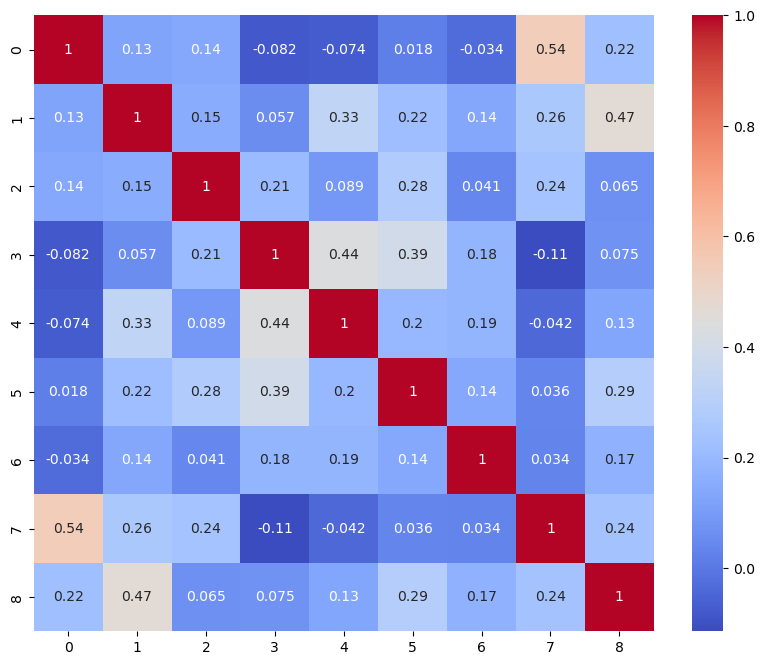

In [6]:
# 绘制特征相关性热力图
# corr()计算相关系数，观察各个指标之间、指标与标签的关联强弱
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()


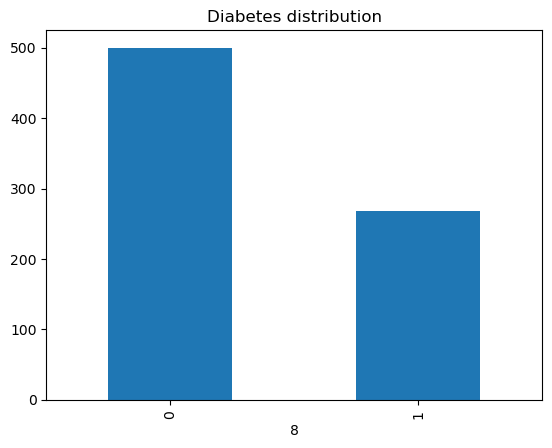

In [7]:
# 查看标签列的样本分布，统计患病与未患病人数
# 判断数据集是否类别不平衡，对后续模型结果解读有参考意义
df.iloc[:,-1].value_counts().plot(kind="bar")
plt.title("Diabetes distribution")
plt.show()


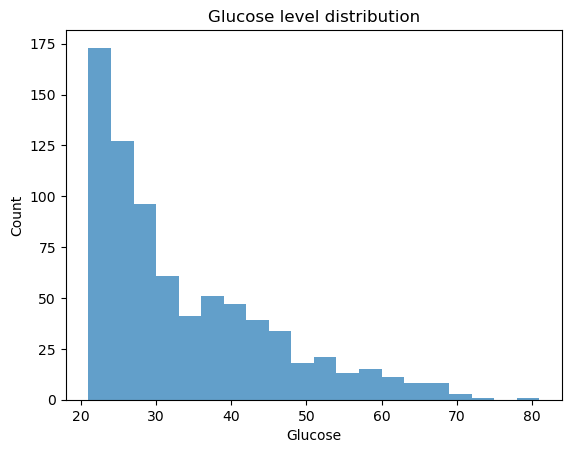

In [8]:
# 绘制血糖特征的分布直方图
# 观察血糖数值的整体分布范围、集中趋势，查看是否存在异常值
plt.hist(df.iloc[:,7],bins=20,alpha=0.7)
plt.xlabel("Glucose")
plt.ylabel("Count")
plt.title("Glucose level distribution")
plt.show()


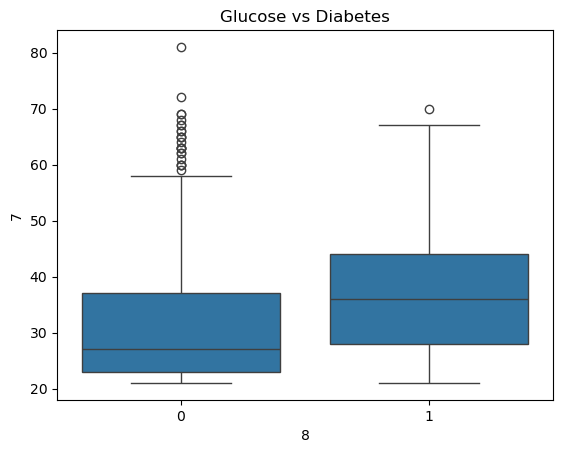

In [9]:
# 箱线图对比血糖在患病、未患病两组之间的数值差异
# 同时可以观察每一组内部的离散程度和离群异常点
sns.boxplot(x=df.iloc[:,-1],y=df.iloc[:,7])
plt.title("Glucose vs Diabetes")
plt.show()


In [10]:
# 导入机器学习工具包
# train_test_split划分数据集，LogisticRegression逻辑回归分类器
# accuracy_score、classification_report、confusion_matrix用来评估模型效果
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [11]:
# iloc[:,:-1]取全部列除最后一列作为输入特征X
# iloc[:,-1]取最后一列患病标签作为预测目标y
# test_size=0.3：30%作为测试集，70%用来训练
# random_state=42固定随机种子，保证每次拆分结果一致，方便复现
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


准确率： 0.7359307359307359
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       151
           1       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



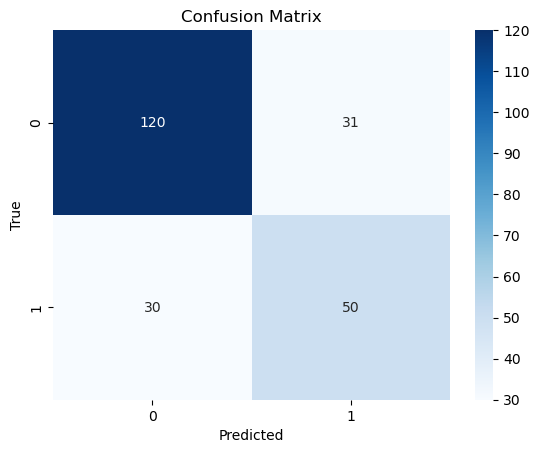

In [12]:
# 划分特征X与标签y，按7:3拆分训练集与测试集
# 构建逻辑回归模型，max_iter=1000增大迭代次数保证收敛
# 在训练集拟合模型，对测试集预测并输出各项评估指标
# 绘制混淆矩阵热力图，直观观察预测正确与错误样本数量
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("准确率：", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
